# Project - Joaquin Carlos Garcia De Joya

In [1]:
import numpy as np                #importing needed modules
from astropy.table import Table
from astropy.io import ascii
import matplotlib.pyplot as plt
from scipy import optimize

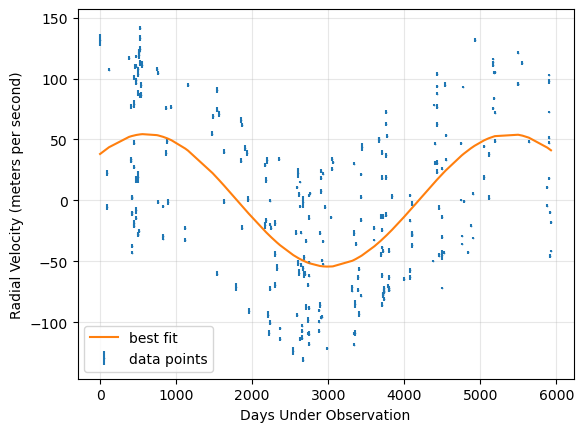

In [2]:
astrodata = ascii.read('data.txt')                #extracting the data we need

def f_model(x,a,b,c,d):                                #defining the best of fit function
    return a*np.cos(2*np.pi*(x-b)/c) + d

#because our HJD data is too large, they will be changed to start from 0, yet keep their interval lengths
#labels are changed accordingly
nparray_x = np.array(astrodata['HJD']) #converting ascii to numpy array data
nparray_subtract = np.full_like(nparray_x,2449676.0632) #creating an array and subtracting the minimum HJD value from each x-value
nparray_HJDtransform = nparray_x - nparray_subtract   #final value

f, ax = plt.subplots()        #creating plots
zerr = astrodata['Radial_Velocity_Uncertainty']
ax.errorbar(nparray_HJDtransform,astrodata['Radial_Velocity'],yerr=zerr,fmt='o',markersize=0.2,label='data points')

param_guess = [142.5,0,5927.74084,7.5]      #making use of scipy
#input the best-fit function, transformed x-coordinates, y-coordinates to fit to, and the guess
best_params, _ = optimize.curve_fit(f_model,nparray_HJDtransform,astrodata['Radial_Velocity'],p0=param_guess)
best_a = best_params[0] #setting the optimized values to be equal to variables for use in the future
best_b = best_params[1]
best_c = best_params[2]
best_d = best_params[3]

y_fit = best_a*np.cos(2*np.pi*(nparray_HJDtransform-best_b)/best_c) + best_d    #graphing our best-fit function with the optimized values
ax.plot(nparray_HJDtransform,y_fit,label='best fit')           #legends and labels
ax.set_xlabel('Days Under Observation')
ax.set_ylabel('Radial Velocity (meters per second)')
plt.legend(loc=0)
plt.grid(alpha=0.3)

#### We're extracting the raw astronomical data and modeling our star's radial velocity over time by defining a sinusoidal function. Our curve_fit library is being utilized to align the model with the observed data points, therefore creating a visual representation of a planet's gravity pulling on its host star.

The optimized amplitude value is 54.3927
The optimized period value is 4777.3519


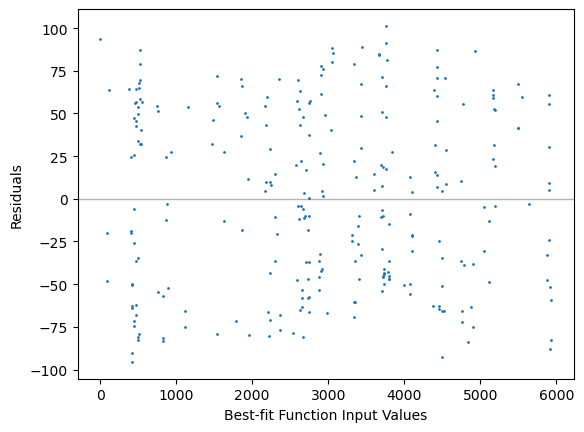

In [4]:
residuals = astrodata['Radial_Velocity'] - y_fit          #calculating the difference between the actual data and our best-fit function


plt.plot(nparray_HJDtransform,residuals,'o',markersize=1)  #plotting residuals
plt.xlabel('Best-fit Function Input Values')
plt.ylabel('Residuals')
plt.axhline(y=0,color='k',alpha=0.3,linewidth=1.0)
print(f'The optimized amplitude value is {best_a:0.4f}')
print(f'The optimized period value is {best_c:0.4f}')

#### For this part, we calculated the residuals, which are the differences between our observed data and the values predicted by the best-fit model. The residuals are then plotted on a scatter chart, which allows us to check if there are any noticeable patterns or potential errors from our data. In addition, our code printed the optimized values for both the star's orbital period and velocity amplitude, as seen from our printed statements.

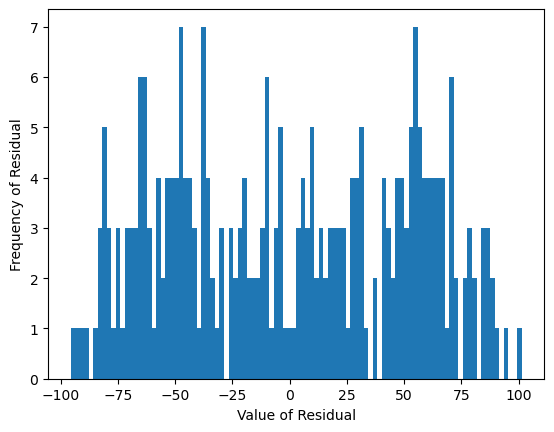

In [5]:
plt.hist(residuals,bins=100)      #forming our histograms
plt.xlabel('Value of Residual')
plt.ylabel('Frequency of Residual')
std_residuals = np.std(residuals)
mean_residuals = np.mean(residuals)

In [6]:
print(f'The standard deviation of the residuals is {std_residuals:0.4f}.')

The standard deviation of the residuals is 51.9506.


In [8]:
K = best_a
P = best_c
M_EXO = (K/28.4) * ((P/365)**(1/3)) * (0.26)**(2/3)        #formula for the mass of the exoplanet in multiples of jupiter's mass
print(f'The mass of the exoplanet is around {M_EXO:0.3f} times Jupiter\'s mass.')

The mass of the exoplanet is around 1.839 times Jupiter's mass.


#### Using a histogram, we are looking to see if the measurement noise from our distribution of residuals follows a standard bell curve. In additon, we are calculating the mass of the exoplanet by setting up a physical formula for our optimized parameters. Our final product shows the mass of the exoplanet to be an estimated 1.839 times the mass of Jupiter, giving proof to the idea that our planet is a gas giant.

# Our analysis shows that the planet closely fits 55 Cnc d.